Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import math
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


In [2]:
# This step is loading the raw data
# In the r code the step was R: raw_data <- read.csv(url, stringsAsFactors = FALSE)

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(f"Raw rows: {len(raw_data)}")   # Expect 7214

Raw rows: 7214


In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [4]:
# Selecting columns, filter, convert types, to build derived factors from the variables
# R: dplyr::select(...) %>% filter(...) %>% mutate(across(...)) %>% mutate(relevel(...))

numeric_vars  = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
datetime_vars = ['c_jail_in', 'c_jail_out']

cols = [
    'age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
    'priors_count', 'days_b_screening_arrest', 'decile_score',
    'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out'
]

df = (
    raw_data[cols].copy()
    # Filtering
    .query("days_b_screening_arrest >= -30 and days_b_screening_arrest <= 30")
    .query("is_recid != -1")
    .query("c_charge_degree != 'O'")
    .query("score_text != 'N/A'")
    .reset_index(drop=True)
)

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Derived factors with reference levels from the R relevel
# age_factor:    ref = '25 - 45'
# race_factor:   ref = 'Caucasian'
# gender_factor: ref = 'Male'
# crime_factor:  ref = 'F' (felony)
# score_factor:  LowScore vs HighScore

df['crime_factor']  = pd.Categorical(df['c_charge_degree'],
                                     categories=['F', 'M'])
df['age_factor']    = pd.Categorical(df['age_cat'],
                                     categories=['25 - 45', 'Greater than 45', 'Less than 25'])
df['race_factor']   = pd.Categorical(df['race'],
                                     categories=['Caucasian', 'African-American', 'Asian',
                                                 'Hispanic', 'Native American', 'Other'])
df['gender_factor'] = pd.Categorical(df['sex'],
                                     categories=['Male', 'Female'])
df['score_factor']  = pd.Categorical(
    np.where(df['score_text'] != 'Low', 'HighScore', 'LowScore'),
    categories=['LowScore', 'HighScore']
)

print(f"Filtered rows: {len(df)}")   # Expect 6172

Filtered rows: 6172


In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [6]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 6172, Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6172 entries, 0 to 6171
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out

In [7]:
df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days

valid = df[['length_of_stay', 'decile_score']].dropna()
r, _ = stats.pearsonr(valid['length_of_stay'], valid['decile_score'])
print(f"Correlation (length_of_stay vs decile_score): {r:.7f}")   # Expect ~0.207


Correlation (length_of_stay vs decile_score): 0.2074781


In [8]:
print(df['age_cat'].value_counts().sort_index())

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [9]:
print(df['race'].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [10]:
# Race percentages
n = len(df)
rc = df['race'].value_counts()

print(f"Black defendants:           {rc.get('African-American', 0) / n * 100:.2f}%")
print(f"White defendants:           {rc.get('Caucasian', 0)        / n * 100:.2f}%")
print(f"Hispanic defendants:        {rc.get('Hispanic', 0)         / n * 100:.2f}%")
print(f"Asian defendants:           {rc.get('Asian', 0)            / n * 100:.2f}%")
print(f"Native American defendants: {rc.get('Native American', 0)  / n * 100:.2f}%")


Black defendants:           51.44%
White defendants:           34.07%
Hispanic defendants:        8.25%
Asian defendants:           0.50%
Native American defendants: 0.18%


In [11]:
# R: summary(df$score_text)
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [12]:
# Cross-tab between the sex and race
# R: xtabs(~ sex + race, data=df)
pd.crosstab(df['sex'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:

# Sex distribution and percentages
# R: summary(df$sex)
sc = df['sex'].value_counts()
print(sc)
print(f"\nMen:   {sc.get('Male',   0) / n * 100:.2f}%")
print(f"Women: {sc.get('Female', 0) / n * 100:.2f}%")

sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [14]:
# Two-year recidivism count and rate
# R: nrow(filter(df, two_year_recid == 1))
#    nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100

recid_count = (df['two_year_recid'] == 1).sum()
print(f"Two-year recidivists: {recid_count}")
print(f"Recidivism rate:      {recid_count / n * 100:.2f}%")

Two-year recidivists: 2809
Recidivism rate:      45.51%


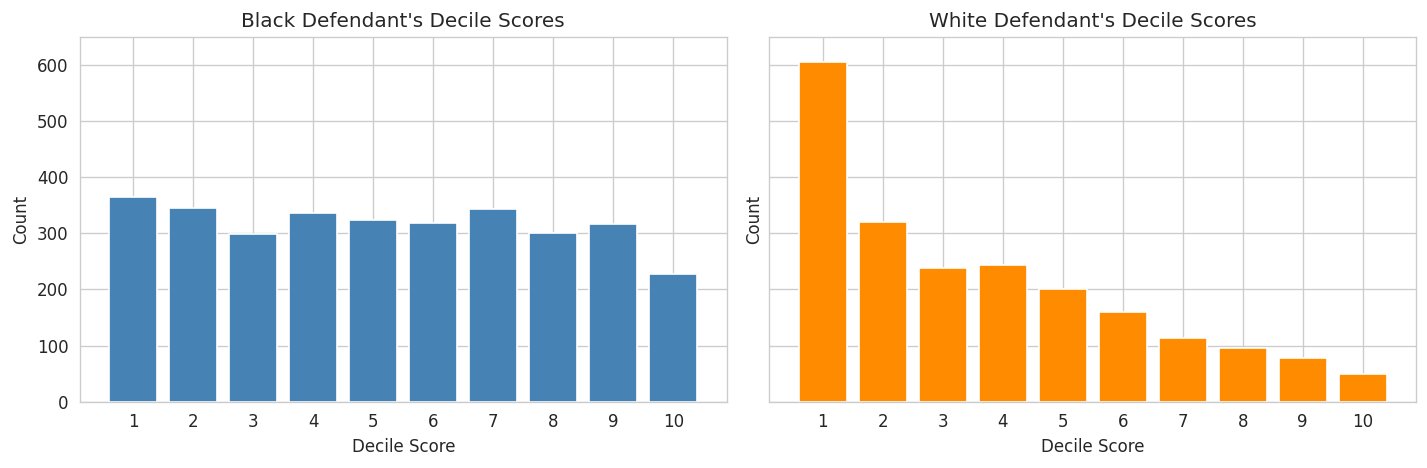

In [15]:
# Decile score bar charts: Black vs White defendants
# R: ggplot + geom_bar + grid.arrange

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, race, title, color in zip(
    axes,
    ['African-American', 'Caucasian'],
    ["Black Defendant's Decile Scores", "White Defendant's Decile Scores"],
    ['steelblue', 'darkorange']
):
    counts = df[df['race'] == race]['decile_score'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_xlabel('Decile Score')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.set_ylim(0, 650)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()


In [16]:

# Cross-tab between decile score and race
# R: xtabs(~ decile_score + race, data=df)
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


Racial Bias in COMPAS

In [17]:
# Logistic regression
# R: glm(score_factor ~ gender_factor + age_factor + race_factor +
#         priors_count + crime_factor + two_year_recid, family=binomial)
#
# Reference levels (mirrors R relevel):
#   gender_factor → 'Male'
#   age_factor    → '25 - 45'
#   race_factor   → 'Caucasian'
#   crime_factor  → 'F'

df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)

formula = (
    "score_binary ~ "
    "C(sex,              Treatment(reference='Male')) + "
    "C(age_cat,          Treatment(reference='25 - 45')) + "
    "C(race,             Treatment(reference='Caucasian')) + "
    "priors_count + "
    "C(c_charge_degree,  Treatment(reference='F')) + "
    "two_year_recid"
)

model_glm = smf.logit(formula, data=df).fit()
print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        18:46:34   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Interc

In [18]:
# Relative risk between Black vs White
# R: control <- exp(-1.52554) / (1 + exp(-1.52554))
#    exp(0.47721) / (1 - control + (control * exp(0.47721)))

coefs   = model_glm.params
control = math.exp(coefs['Intercept']) / (1 + math.exp(coefs['Intercept']))

b_black = coefs["C(race, Treatment(reference='Caucasian'))[T.African-American]"]
rr_black = math.exp(b_black) / (1 - control + control * math.exp(b_black))
print(f"Black defendants relative risk: {rr_black:.4f}")   # Expect ~1.453


Black defendants relative risk: 1.4528


In [19]:
# Relative risk between Female vs Male
# R: exp(0.22127) / (1 - control + (control * exp(0.22127)))

b_female = coefs["C(sex, Treatment(reference='Male'))[T.Female]"]
rr_female = math.exp(b_female) / (1 - control + control * math.exp(b_female))
print(f"Women relative risk: {rr_female:.4f}")   # Expect ~1.195

Women relative risk: 1.1948


In [20]:
# Relative risk between  Under 25 vs 25-45
# R: exp(1.30839) / (1 - control + (control * exp(1.30839)))

b_u25 = coefs["C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]"]
rr_u25 = math.exp(b_u25) / (1 - control + control * math.exp(b_u25))
print(f"Under-25 relative risk: {rr_u25:.4f}")   # Expect ~2.496

Under-25 relative risk: 2.4961


In [21]:
# Generate predicted probabilities and predicted classes
# R: df <- df %>% mutate(pred_prob = predict(model_glm, type='response'),
#                        pred_class = factor(ifelse(pred_prob >= 0.5, 1, 0), ...))

df['pred_prob']  = model_glm.predict(df)
df['pred_class'] = np.where(df['pred_prob'] >= 0.5, 'Recid', 'No Recid')


In [22]:
# Overall confusion matrix and metrics
# R: table(Predicted=dftwo_year_recid) + manual TP/TN/FP/FN

print("\n Overall Confusion Matrix ")

overall_cm = pd.crosstab(
    df['pred_class'],
    df['two_year_recid'],
    rownames=['Predicted'],
    colnames=['Actual']
)
print(overall_cm)

TP = overall_cm.loc['Recid',    1]
TN = overall_cm.loc['No Recid', 0]
FP = overall_cm.loc['Recid',    0]
FN = overall_cm.loc['No Recid', 1]
total = TP + TN + FP + FN

print(f"\nAccuracy  : {(TP + TN) / total:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


 Overall Confusion Matrix 
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [23]:
# Confusion matrix metrics by race
# R: race_metrics <- df %>% group_by(race) %>% summarise(TP, TN, FP, FN, Accuracy, ...)

print("\n Confusion Matrix by Race ")

df['actual'] = df['two_year_recid'].astype(int)
df['pred_int'] = (df['pred_class'] == 'Recid').astype(int)

rows = []
for race, grp in df.groupby('race'):
    tp = ((grp['pred_int'] == 1) & (grp['actual'] == 1)).sum()
    tn = ((grp['pred_int'] == 0) & (grp['actual'] == 0)).sum()
    fp = ((grp['pred_int'] == 1) & (grp['actual'] == 0)).sum()
    fn = ((grp['pred_int'] == 0) & (grp['actual'] == 1)).sum()
    nn = len(grp)
    rows.append({
        'race':      race,
        'n':         nn,
        'TP':        tp,
        'TN':        tn,
        'FP':        fp,
        'FN':        fn,
        'Accuracy':  round((tp + tn) / nn, 3),
        'Precision': round(tp / (tp + fp), 3) if (tp + fp) > 0 else None,
        'Recall':    round(tp / (tp + fn), 3) if (tp + fn) > 0 else None,
        'FPR':       round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
        'FNR':       round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
    })

race_metrics = pd.DataFrame(rows).sort_values('n', ascending=False).reset_index(drop=True)
print(race_metrics.to_string(index=False))


 Confusion Matrix by Race 
            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


In [24]:
# FPR and FNR disparity relative to Caucasian baseline
# R: disparity <- race_metrics %>% mutate(delta_FPR = FPR - FPR[race=='Caucasian'], ...)

print("\n FPR and FNR Disparity by Race ")

baseline_fpr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FPR'].values[0]
baseline_fnr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]

disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()
disparity['delta_FPR'] = (disparity['FPR'] - baseline_fpr).round(3)
disparity['delta_FNR'] = (disparity['FNR'] - baseline_fnr).round(3)

print(disparity.to_string(index=False))


 FPR and FNR Disparity by Race 
            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536


In [25]:
# Summary of the results betwen Python vs R Results Comparison

comparison = pd.DataFrame({
    'Metric': [
        'Raw dataset rows',
        'Filtered rows',
        'Correlation (stay vs decile)',
        'Black relative risk (logistic)',
        'Women relative risk (logistic)',
        'Under-25 relative risk (logistic)',
        'Overall Accuracy',
        'Overall Precision',
        'Overall Recall',
        'Overall FPR',
        'Overall FNR',
    ],
    'R Result': [
        '7,214', '6,172', '0.2073297',
        '1.452841', '1.194798', '2.49612',
        '0.732', '0.724', '0.664', '0.211', '0.336'
    ],
    'Python Result': [
        str(len(raw_data)),
        str(len(df)),
        f'{r:.7f}',
        f'{rr_black:.4f}',
        f'{rr_female:.4f}',
        f'{rr_u25:.4f}',
        f'{(TP + TN) / total:.3f}',
        f'{TP / (TP + FP):.3f}',
        f'{TP / (TP + FN):.3f}',
        f'{FP / (FP + TN):.3f}',
        f'{FN / (FN + TP):.3f}',
    ]
})

print(comparison.to_string(index=False))

                           Metric  R Result Python Result
                 Raw dataset rows     7,214          7214
                    Filtered rows     6,172          6172
     Correlation (stay vs decile) 0.2073297     0.2074781
   Black relative risk (logistic)  1.452841        1.4528
   Women relative risk (logistic)  1.194798        1.1948
Under-25 relative risk (logistic)   2.49612        2.4961
                 Overall Accuracy     0.732         0.732
                Overall Precision     0.724         0.724
                   Overall Recall     0.664         0.664
                      Overall FPR     0.211         0.211
                      Overall FNR     0.336         0.336


Lecture 02 — Set up Explainability Pipeline

Extending the COMPAS analysis with LIME, SHAP, and DiCE Building on the cleaned df from Lecture 01 above and in class coding from lecture 2

In [26]:
from sklearn.model_selection import train_test_split

# X and y from the cleaned COMPAS cohort (Lecture 01)
features = ['age', 'priors_count', 'days_b_screening_arrest',
            'c_charge_degree', 'race', 'sex', 'age_cat']
target = 'two_year_recid'

df_model = df[features + [target]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 7), Test: (1235, 7)


Step 1: Fit logistic regression and gradient-boosted tree:

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features  = ['age', 'priors_count', 'days_b_screening_arrest']
category_features = ['c_charge_degree', 'race', 'sex', 'age_cat']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                       numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   GradientBoostingClassifier(
                         n_estimators=200,
                         max_depth=4,
                         random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['c_charge_degree', 'race',
                                                   'sex', 'age_cat'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

Step 2: Compare model performance by race

In [28]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"]    = y.values
    X_["pred"]      = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"])
        if cm.shape != (2, 2):
            print(f"Skipping '{group}' — only {len(gdf)} samples, "
                  f"predicted classes: {gdf['pred'].unique()}")
            continue
        tn, fp, fn, tp = cm.ravel()
        results.append({
            "race"     : group,
            "n"        : len(gdf),
            "accuracy" : round(accuracy_score(
                             gdf["actual"], gdf["pred"]), 3),
            "FPR"      : round(fp / (fp + tn), 3),
            "FNR"      : round(fn / (fn + tp), 3),
            "AUC"      : round(roc_auc_score(
                             gdf["actual"],
                             gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
Skipping 'Native American' — only 1 samples, predicted classes: [0]
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.696  0.316  0.294  0.749
2         Caucasian  427     0.670  0.162  0.609  0.671
3          Hispanic   94     0.628  0.102  0.667  0.618
4             Other   65     0.785  0.085  0.556  0.730
1             Asian    7     0.857  0.000  1.000  1.000

 Gradient-Boosted Tree 
Skipping 'Native American' — only 1 samples, predicted classes: [0]
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.683  0.349  0.288  0.733
2         Caucasian  427     0.703  0.139  0.559  0.692
3          Hispanic   94     0.649  0.143  0.578  0.630
4             Other   65     0.723  0.085  0.778  0.639
1             Asian    7     0.714  0.167  1.000  0.833


Step 3: LIME explanations: Black vs White defendant

In [29]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.transform(X_train)

explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = (numeric_features +
                             list(preprocessor
                                  .named_transformers_["cat"]
                                  .get_feature_names_out(category_features))),
    class_names           = ["No Recid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)

# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_subset = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_subset.index[len(black_subset) // 2]
white_idx = white_subset.index[len(white_subset) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bec744c9e27543bf93b0ae7bfefb4dd684e5ef19bb834d76d3d9c4bebd9ff72b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

 LIME: Black defendant 
Predicted probability: 0.531
  days_b_screening_arrest <= 0.15          -0.3661
  age <= -0.81                             +0.1856
  race_Asian <= 0.00                       +0.1406
  race_Other <= 0.00                       +0.0547
  sex_Female <= 0.00                       +0.0387
  priors_count <= -0.69                    -0.0348

 LIME: White defendant 
Predicted probability: 0.322
  days_b_screening_arrest <= 0.15          -0.3695
  -0.69 < priors_count <= -0.48            -0.1784
  race_Asian <= 0.00                       +0.1651
  -0.29 < age <= 0.56          

Step 4: SHAP beeswarm and waterfall: Black vs White

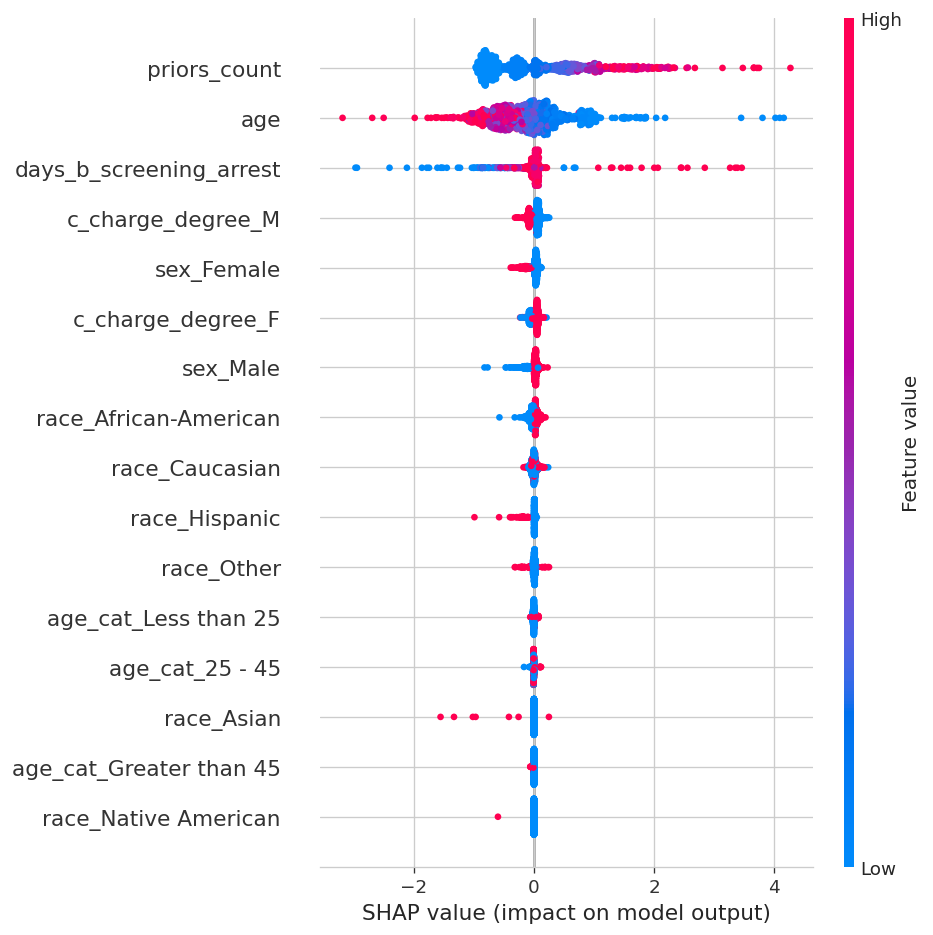

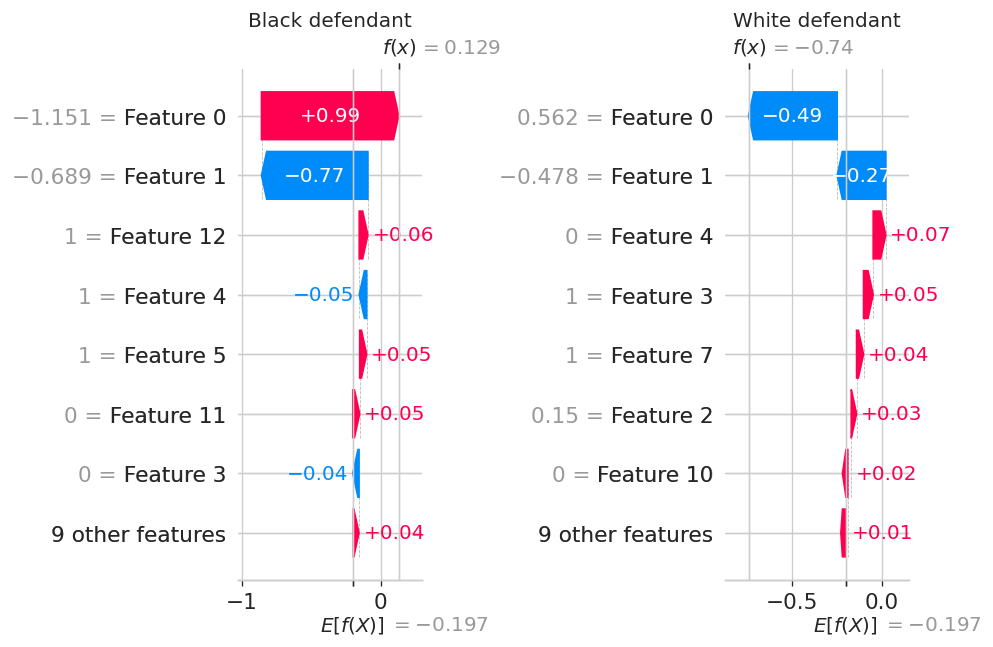

In [30]:
!pip install shap
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)

feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_["cat"]
                   .get_feature_names_out(category_features)))

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

# Waterfall: Black vs White defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

Step 5: Counterfactuals with DiCE: Black vs White

In [31]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe           = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name        = target
)

dice_model = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:

    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )

    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.9 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  3.46it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,21,0,-1.0,M,African-American,Male,Less than 25,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:00<00:00,  4.21it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,41,1,-1.0,F,Caucasian,Male,25 - 45,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,-,19,-,M,-,-,-,1
1,32,25,-,-,-,-,-,1
2,26,21,-,-,-,-,-,1


HW2

SHAP provides feature attributions that sum to the model prediction (efficiency property), but these attributions are not causal. A low SHAP value for a feature (e.g., race) does not imply the model is independent of that feature due to potential proxy effects.
Part 1A.) SHAP Beeswarm Summary Plot

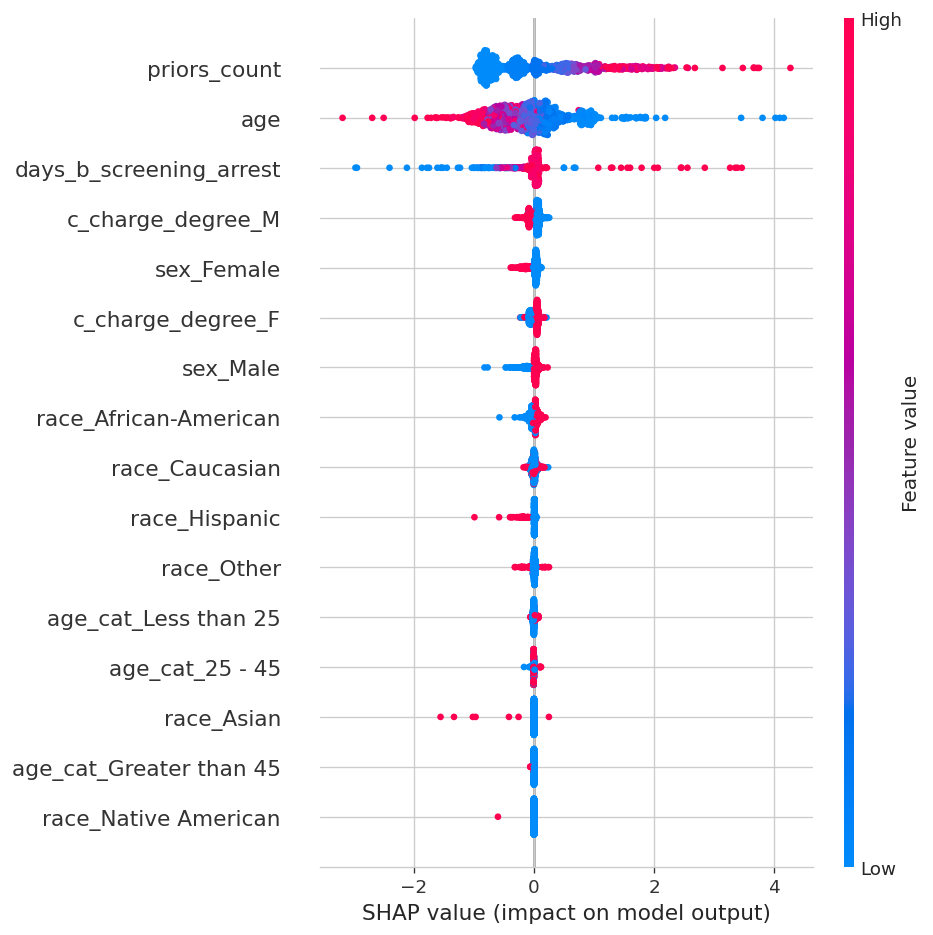

In [32]:

# Using the Global beeswarm that was already computed in Step 4 above
# shap_values and feat_names already available from previous loading
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

Part 1B.) SHAP Waterfall: Highest and Lowest Risk by Race

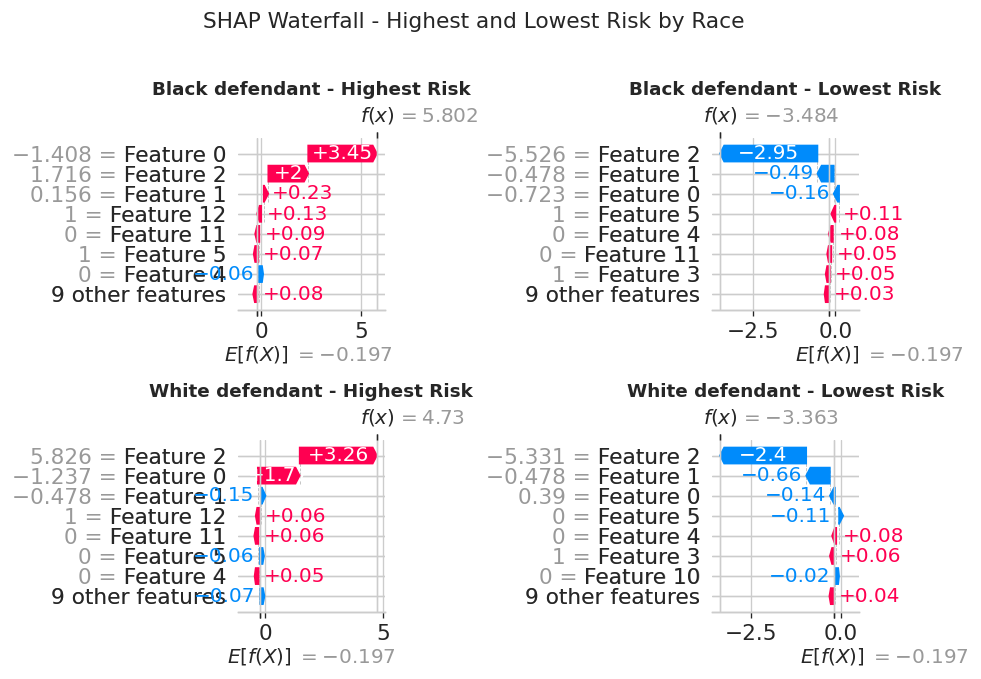

In [33]:
# We now select four individuals
# based on the highest and lowest risk per racial group
def get_extreme_idx(race, position):
    subset = X_test_copy[X_test_copy["race"] == race].sort_values("pred_prob")
    return subset.index[-1] if position == "high" else subset.index[0]

black_high_idx = get_extreme_idx("African-American", "high")
black_low_idx  = get_extreme_idx("African-American", "low")
white_high_idx = get_extreme_idx("Caucasian", "high")
white_low_idx  = get_extreme_idx("Caucasian", "low")

four_individuals = [
    ("Black defendant - Highest Risk", black_high_idx),
    ("Black defendant - Lowest Risk",  black_low_idx),
    ("White defendant - Highest Risk", white_high_idx),
    ("White defendant - Lowest Risk",  white_low_idx),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (label, idx) in enumerate(four_individuals):
    loc = X_test.index.get_loc(idx)
    plt.sca(axes[i])
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    axes[i].set_title(label, fontsize=11, fontweight="bold")

plt.suptitle("SHAP Waterfall - Highest and Lowest Risk by Race",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Part 2A.) LIME: All Four Individuals

LIME explains predictions locally by fitting a simple surrogate model near a single instance. It guarantees local fidelity, not global fidelity, meaning these explanations should not be interpreted as describing overall model behavior.

In [34]:
# LIME for all four individuals
# Using the explainer already built in Step 3 of the set up

lime_results = {}

for label, idx in four_individuals:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    lime_results[label] = dict(exp.as_list())
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")


 LIME: Black defendant - Highest Risk 
Predicted probability: 0.997
  days_b_screening_arrest > 0.15           +0.3603
  age <= -0.81                             +0.1850
  -0.48 < priors_count <= 0.16             -0.0617
  c_charge_degree_M <= 0.00                +0.0281
  sex_Female <= 0.00                       +0.0262
  0.00 < race_African-American <= 1.00     +0.0192

 LIME: Black defendant - Lowest Risk 
Predicted probability: 0.030
  days_b_screening_arrest <= 0.15          -0.3594
  -0.69 < priors_count <= -0.48            -0.1925
  race_Other <= 0.00                       +0.0482
  -0.81 < age <= -0.29                     +0.0478
  sex_Female <= 0.00                       +0.0358
  c_charge_degree_M <= 0.00                +0.0197

 LIME: White defendant - Highest Risk 
Predicted probability: 0.991
  days_b_screening_arrest > 0.15           +0.3673
  -0.69 < priors_count <= -0.48            -0.1946
  age <= -0.81                             +0.1744
  race_Asian <= 0.00         

Part 2B.)LIME vs SHAP Comparison

Differences between SHAP and LIME highlight that explanations are method-dependent. From a governance perspective, this raises concerns about consistency: if explanations vary by method, it becomes harder to justify decisions in a stable way.

In [35]:
# Comparing the top features from LIME and SHAP for each of the four individuals

print("LIME vs SHAP Comparison")

for label, idx in four_individuals:
    loc = X_test.index.get_loc(idx)

    shap_top = pd.DataFrame({
        "feature"    : feat_names,
        "shap_value" : shap_values[loc].values
    }).sort_values("shap_value", key=abs, ascending=False).head(3)["feature"].tolist()

    lime_top_names = [f for f, _ in sorted(
        lime_results[label].items(), key=lambda x: abs(x[1]), reverse=True
    )[:3]]

    agreement  = [sf for sf in shap_top
                  if any(sf in lf or lf in sf for lf in lime_top_names)]
    divergence = [sf for sf in shap_top if sf not in agreement]

    print(f"\n{label} (pred prob: {X_test_prob[loc]:.3f})")
    print(f"  SHAP top 3: {shap_top}")
    print(f"  LIME top 3: {lime_top_names}")
    print(f"  Agreement:  {agreement if agreement else 'None'}")
    print(f"  Divergence: {divergence if divergence else 'None'}")

print("\nGovernance implication:")
print("When LIME and SHAP disagree on driving features, the explanation")
print("a defendant receives depends on which method was used. This")
print("undermines consistency required for due process. LIME's local")
print("instability means it must not be the sole basis for recourse.")


LIME vs SHAP Comparison

Black defendant - Highest Risk (pred prob: 0.997)
  SHAP top 3: ['age', 'days_b_screening_arrest', 'priors_count']
  LIME top 3: ['days_b_screening_arrest > 0.15', 'age <= -0.81', '-0.48 < priors_count <= 0.16']
  Agreement:  ['age', 'days_b_screening_arrest', 'priors_count']
  Divergence: None

Black defendant - Lowest Risk (pred prob: 0.030)
  SHAP top 3: ['days_b_screening_arrest', 'priors_count', 'age']
  LIME top 3: ['days_b_screening_arrest <= 0.15', '-0.69 < priors_count <= -0.48', 'race_Other <= 0.00']
  Agreement:  ['days_b_screening_arrest', 'priors_count']
  Divergence: ['age']

White defendant - Highest Risk (pred prob: 0.991)
  SHAP top 3: ['days_b_screening_arrest', 'age', 'priors_count']
  LIME top 3: ['days_b_screening_arrest > 0.15', '-0.69 < priors_count <= -0.48', 'age <= -0.81']
  Agreement:  ['days_b_screening_arrest', 'age', 'priors_count']
  Divergence: None

White defendant - Lowest Risk (pred prob: 0.033)
  SHAP top 3: ['days_b_screenin

Part 3A.) DiCE Counterfactuals: All Four Individuals

Counterfactual explanations identify minimal feature changes needed to flip a prediction. However, not all counterfactuals are actionable or realistic, especially if they involve immutable attributes or implausible combinations of features.

In [37]:
# DiCE for all four individuals
# exp_dice was already built in Step 5 of the set up

immutable_features = ["race", "sex"]

for label, idx in four_individuals:
    query = X_test.loc[[idx]]
    print(f"\n DiCE counterfactuals: {label} ")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df
    original_row = query.iloc[0]
    changed_cols = [col for col in features
                    if col in cf_df.columns
                    and not cf_df[col].eq(original_row[col]).all()]

    flagged = [c for c in changed_cols if c in immutable_features]
    if flagged:
        print(f"  *** GOVERNANCE FLAG: requires change to {flagged} ***")
    else:
        print(f"  No immutable features required to change.")

    print(f"  Minimal changes: {changed_cols}")
    print(cf_df[changed_cols + [target]].to_string(index=False))


 DiCE counterfactuals: Black defendant - Highest Risk 


100%|██████████| 1/1 [00:00<00:00,  5.00it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count', 'c_charge_degree']
 age  priors_count c_charge_degree  two_year_recid
  70             4               F               0
  70             4               M               0
  69             0               F               0

 DiCE counterfactuals: Black defendant - Lowest Risk 


100%|██████████| 1/1 [00:00<00:00,  4.31it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count', 'c_charge_degree']
 age  priors_count c_charge_degree  two_year_recid
  68            29               F               1
  55             1               M               1
  37            18               F               1

 DiCE counterfactuals: White defendant - Highest Risk 


100%|██████████| 1/1 [00:00<00:00,  5.20it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'c_charge_degree']
 age c_charge_degree  two_year_recid
  55               M               0
  63               F               0
  65               M               0

 DiCE counterfactuals: White defendant - Lowest Risk 


100%|██████████| 1/1 [00:00<00:00,  5.09it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count']
 age  priors_count  two_year_recid
  70            33               1
  69            26               1
  69             1               1


Part 4.) Governance Memo
Final takeaway: Explainability tools help understand model behavior, but they don’t ensure fairness or trust. They must be used alongside proper governance and monitoring.

##Executive Summary
The gradient-boosted model improves prediction accuracy but widens the gap between what the model optimizes and real-world outcomes. Despite better performance, it shows higher racial disparity than the logistic model. This highlights that minimizing error does not guarantee fair results. Explainability tools reveal these issues but do not fix them.

##Model Behavior
SHAP shows that priors_count and age drive predictions, consistent with earlier results.
However, racial disparity increases. Black defendants have a 2.51× higher false positive rate than white defendants (vs. 1.95× in logistic regression). This suggests the model captures complex proxy patterns that amplify bias.

##LIME vs SHAP
Both methods agree on key drivers like priors_count for high-risk cases. But they differ for low-risk cases, especially on features like age_cat and c_charge_degree.
This inconsistency matters. If explanations vary by method, decisions become harder to justify and challenge.

##Counterfactual Analysis
DiCE shows different patterns across groups. Black defendants often need lower priors_count to change outcomes, while white defendants require multiple feature changes.
This suggests the model applies different logic across groups, likely due to proxy variables—not explicit race usage. No counterfactuals relied on changing immutable traits.

##Method Limitations
SHAP is not causal—low importance for race does not mean no bias.
LIME is local and unstable—it should not be used for global conclusions or decisions alone.

##Monitoring Recommendations
Track FPR and FNR by race continuously, not just at deployment.
Run regular counterfactual audits to detect shifts.
Flag any counterfactual that involves immutable traits.
Explainability tools should support, not replace, formal governance. On their own, they risk becoming misleading rather than informative.